In [1]:
# from huggingface_hub import hf_hub_download

# hf_hub_download(repo_id="FoivosPar/Arc2Face", filename="arc2face/config.json", local_dir="./models")
# hf_hub_download(repo_id="FoivosPar/Arc2Face", filename="arc2face/diffusion_pytorch_model.safetensors", local_dir="./models")
# hf_hub_download(repo_id="FoivosPar/Arc2Face", filename="encoder/config.json", local_dir="./models")
# hf_hub_download(repo_id="FoivosPar/Arc2Face", filename="encoder/pytorch_model.bin", local_dir="./models")

In [2]:
# %pip install -U onnxruntime-gpu

In [ ]:
# url = "https://drive.google.com/file/d/18wEUfMNohBJ4K3Ly5wpTejPfDzp-8fI8/view"
# import gdown
# gdown.download(url, "antelopev2.zip", quiet=False, fuzzy=True)

Downloading...
From (original): https://drive.google.com/uc?id=18wEUfMNohBJ4K3Ly5wpTejPfDzp-8fI8
From (redirected): https://drive.google.com/uc?id=18wEUfMNohBJ4K3Ly5wpTejPfDzp-8fI8&confirm=t&uuid=ec9769d5-c88c-40f0-af22-0c04363b4d0e
To: /path/to/FaceLinkGen/fracface/antelopev2.zip
100%|██████████| 361M/361M [00:02<00:00, 125MB/s]  


'antelopev2.zip'

In [54]:
import numpy as np
from PIL import Image

def vstack(images):
    if len(images) == 0:
        raise ValueError("Need 0 or more images")

    if isinstance(images[0], np.ndarray):
        images = [Image.fromarray(img) for img in images]
    width = max([img.size[0] for img in images])
    height = sum([img.size[1] for img in images])
    stacked = Image.new(images[0].mode, (width, height))

    y_pos = 0
    for img in images:
        stacked.paste(img, (0, y_pos))
        y_pos += img.size[1]
    return stacked


def hstack(images):
    if len(images) == 0:
        raise ValueError("Need 0 or more images")

    if isinstance(images[0], np.ndarray):
        images = [Image.fromarray(img) for img in images]
    width = sum([img.size[0] for img in images])
    height = max([img.size[1] for img in images])
    stacked = Image.new(images[0].mode, (width, height))

    x_pos = 0
    for img in images:
        stacked.paste(img, (x_pos, 0))
        x_pos += img.size[0]
    return stacked

In [5]:
# !unzip -d ./models/antelopev2 antelopev2.zip

In [6]:
# hf_hub_download(repo_id="FoivosPar/Arc2Face", filename="arcface.onnx", local_dir="./models/antelopev2")

In [ ]:
import sys
sys.path.append("../../third_party/arc2face")
from diffusers import (
    StableDiffusionPipeline,
    UNet2DConditionModel,
    DPMSolverMultistepScheduler,
)

from arc2face import CLIPTextModelWrapper, project_face_embs

import torch
from insightface.app import FaceAnalysis
from PIL import Image
import numpy as np

base_model = 'stable-diffusion-v1-5/stable-diffusion-v1-5'

encoder = CLIPTextModelWrapper.from_pretrained(
    '../../checkpoints/arc2face', subfolder="encoder", torch_dtype=torch.float16
)

unet = UNet2DConditionModel.from_pretrained(
    '../../checkpoints/arc2face', subfolder="arc2face", torch_dtype=torch.float16
) 

pipeline = StableDiffusionPipeline.from_pretrained(
        base_model,
        text_encoder=encoder,
        unet=unet,
        torch_dtype=torch.float16,
        safety_checker=None
    )

In [2]:
import requests
from io import BytesIO

def compare_faces(img1, img2, api_key, api_secret):
    buf1 = BytesIO()
    img1.save(buf1, format="JPEG")
    buf1.seek(0)

    buf2 = BytesIO()
    img2.save(buf2, format="JPEG")
    buf2.seek(0)

    files = {
        "image_file1": ("img1.jpg", buf1, "image/jpeg"),
        "image_file2": ("img2.jpg", buf2, "image/jpeg")
    }

    data = {
        "api_key": api_key,
        "api_secret": api_secret
    }

    r = requests.post(
        "https://api-us.faceplusplus.com/facepp/v3/compare",
        data=data,
        files=files
    )
    return r.json()

In [3]:
pipeline.scheduler = DPMSolverMultistepScheduler.from_config(pipeline.scheduler.config)
pipeline = pipeline.to('cuda')


In [ ]:
import pickle
with open("../log/insight_student_embeddings_val_epoch_final.pkl", "rb") as f:
    id_embs = pickle.load(f)

In [30]:
import pickle
with open("../../attacks/minusface/test.pkl", "rb") as f:
    id_embs = pickle.load(f)

In [31]:
id_embs["filenames"]

[['/path/to/FaceLinkGen/fracface/test/test.png']]

In [73]:
# import onnxruntime
# app = FaceAnalysis(name='antelopev2', root='./', providers=onnxruntime.get_available_providers())
# app.prepare(ctx_id=0, det_size=(640, 640))
import pickle
with open("../log/insight_student_embeddings_val_epoch_final.pkl", "rb") as f:
    id_embs = pickle.load(f)

In [5]:
len(id_embs["student_embeddings"])

1

In [32]:
fn = id_embs["filenames"][0]
fn = sum(id_embs["filenames"], [])

In [33]:
id_embs["templates"][0].shape  

torch.Size([1, 3, 112, 112])

In [34]:
id_embs["student_embeddings"] = torch.cat(id_embs["student_embeddings"], dim=0)

In [35]:
fn = id_embs["filenames"][0]
fn = sum(id_embs["filenames"], [])
fn = [i.replace("./fracface", "./") for i in fn] 

In [ ]:
fn 

['test/test.png']

In [82]:
levels = []
at_least_one_passed = []
# for idx in range(1000):
idx = 0
id_emb = id_embs["student_embeddings"][idx][None,:].to(torch.float16)
id_emb = (id_emb/torch.norm(id_emb, dim=1, keepdim=True)).to(torch.float16).cuda()
id_emb = project_face_embs(pipeline, id_emb)    # pass through the encoder

images = pipeline(prompt_embeds=id_emb, num_inference_steps=25, guidance_scale=3.0, num_images_per_prompt=5).images
cache = []
for i in range(5):
    res = compare_faces(images[i], Image.open(fn[idx]).convert("RGB"), "YOUR_FACEPP_API_KEY", "YOUR_FACEPP_API_SECRET")
    if len(res['faces2']) == 0:
        print("No face detected")
        continue
    if len(res['faces1']) == 0:
        print("Failed to generate face")
        levels.append("Failed")
        cache.append("Failed")
        continue
    if res["confidence"] > res['thresholds']['1e-5']:
        level = "1e-5"
    elif res["confidence"] > res['thresholds']['1e-4']:
        level = "1e-4"
    elif res["confidence"] > res['thresholds']['1e-3']:
        level = "Failed"
    else:
        level = "Failed"
    cache.append(level)
    levels.append(level)

if any(l != "Failed" for l in cache):
    at_least_one_passed.append(1)
else: 
    at_least_one_passed.append(0)
print("At least one passed score:" , np.mean(at_least_one_passed))

print(level)
success_rate = len([l for l in levels if l != "Failed"])/len(levels)
print(f"Per-image success rate: {success_rate}") 

  0%|          | 0/25 [00:00<?, ?it/s]

100%|██████████| 25/25 [00:06<00:00,  3.73it/s]


At least one passed score: 1.0
1e-5
Per-image success rate: 1.0


In [46]:
levels

['1e-5', '1e-5', '1e-5', '1e-5', '1e-5']

In [ ]:
res = compare_faces(Image.open("stylegan.png").convert("RGB"), Image.open(fn[idx]).convert("RGB"), "YOUR_FACEPP_API_KEY", "YOUR_FACEPP_API_SECRET")

In [107]:
res 

{'request_id': '1766460326,b7cccdf1-d05d-45ef-a852-40d7b0c72d6e',
 'time_used': 252,
 'confidence': 51.677,
 'thresholds': {'1e-3': 62.327, '1e-4': 69.101, '1e-5': 73.975},
 'faces1': [{'face_token': 'bb316fcbc5f4750c8d716121e4f9c95c',
   'face_rectangle': {'top': 72, 'left': 42, 'width': 108, 'height': 108}}],
 'faces2': [{'face_token': '9795bbec7ba2c94df42bc4e1caa89777',
   'face_rectangle': {'top': 27, 'left': 1, 'width': 126, 'height': 126}}],
 'image_id1': '2fs88tGLbC3xdFX6vtAUAA==',
 'image_id2': 'NWMmq/cax1hgDh/PFukSkA=='}

In [55]:
import cv2
from insightface.app import FaceAnalysis
import torch

app = FaceAnalysis(name="buffalo_l", providers=['CUDAExecutionProvider', 'CPUExecutionProvider'])
app.prepare(ctx_id=0, det_size=(160, 160))

Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}, 'CUDAExecutionProvider': {'sdpa_kernel': '0', 'use_tf32': '1', 'fuse_conv_bias': '0', 'prefer_nhwc': '0', 'tunable_op_max_tuning_duration_ms': '0', 'enable_skip_layer_norm_strict_mode': '0', 'tunable_op_tuning_enable': '0', 'tunable_op_enable': '0', 'use_ep_level_unified_stream': '0', 'device_id': '0', 'has_user_compute_stream': '0', 'gpu_external_empty_cache': '0', 'cudnn_conv_algo_search': 'EXHAUSTIVE', 'cudnn_conv1d_pad_to_nc1d': '0', 'gpu_mem_limit': '18446744073709551615', 'gpu_external_alloc': '0', 'gpu_external_free': '0', 'arena_extend_strategy': 'kNextPowerOfTwo', 'do_copy_in_default_stream': '1', 'enable_cuda_graph': '0', 'user_compute_stream': '0', 'cudnn_conv_use_max_workspace': '1'}}
find model: /home/user/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], w

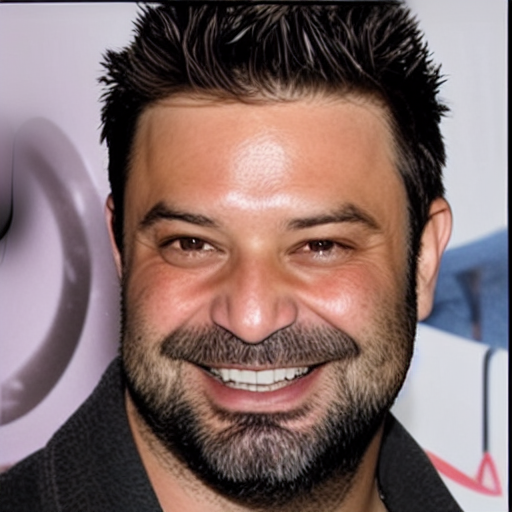

In [104]:
images[2].save("gen.png")
images[2]

In [108]:
res = compare_faces(Image.open("gen.png").convert("RGB"), Image.open(fn[idx]).convert("RGB"), "YOUR_FACEPP_API_KEY", "YOUR_FACEPP_API_SECRET")
res

{'request_id': '1766460341,3ce46554-d84a-419a-ba36-a8234b8ae02a',
 'time_used': 223,
 'confidence': 88.822,
 'thresholds': {'1e-3': 62.327, '1e-4': 69.101, '1e-5': 73.975},
 'faces1': [{'face_token': 'd67596b260f24c34bfa6afdf6abb2ece',
   'face_rectangle': {'top': 205, 'left': 123, 'width': 284, 'height': 284}}],
 'faces2': [{'face_token': '452224dca67249a77dcd82142b58902e',
   'face_rectangle': {'top': 27, 'left': 1, 'width': 126, 'height': 126}}],
 'image_id1': 'kmfwNJTHXpYTphpp2oHvkw==',
 'image_id2': 'NWMmq/cax1hgDh/PFukSkA=='}

In [100]:

image = cv2.imread("gen.png")[:, :, :3]
faces = app.get(image)

gen_faceid_embeds = torch.from_numpy(faces[0].normed_embedding).unsqueeze(0)

image = cv2.imread("test/test.jpg")
faces = app.get(image)
test_faceid_embeds = torch.from_numpy(faces[0].normed_embedding).unsqueeze(0)

image = cv2.imread("stylegan.png")
image = cv2.resize(image, (160, 160))
faces = app.get(image)
stylegan_faceid_embeds = torch.from_numpy(faces[0].normed_embedding).unsqueeze(0)

In [101]:
import torch.nn.functional as F
F.cosine_similarity(gen_faceid_embeds, test_faceid_embeds), F.cosine_similarity(test_faceid_embeds, stylegan_faceid_embeds)

(tensor([0.5437]), tensor([0.1564]))

In [102]:
# np.unique(levels, return_counts=True)